Optimization terminated successfully    (Exit mode 0)
            Current function value: 0.01725950517067341
            Iterations: 7
            Function evaluations: 65
            Gradient evaluations: 7


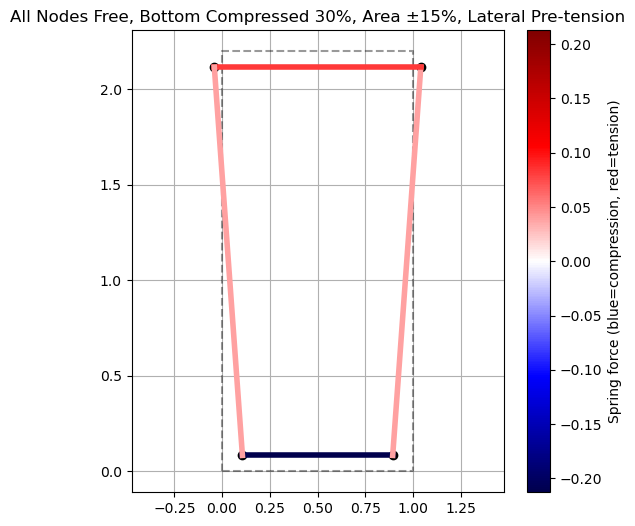

Spring Stiffness k: [1, 1, 1, 1]
Initial Spring Forces (bottom,right,top,left): [0.  0.2 0.  0.2]
Final Spring Forces (bottom,right,top,left): [-0.213  0.039  0.082  0.039]
Initial Area: 2.0
Final Area: 1.9
Initial Height: 2.2
Final Height: 2.033530363816968


In [14]:
#all nodes free, 10% lateral pre-tension, compression not strictly enforced, global shape optimization

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from scipy.optimize import minimize

# -------------------------------
# Parameters
# -------------------------------
width = 1.0
height = 2.0
bottom_compression = 0.7      # 30% compressed
area_relax = 0.05             # ±5% area allowed
tension_factor = .1         # 10% pre-tension in lateral springs

# -------------------------------
# Initial rectangle with lateral pre-tension
# -------------------------------
p0 = np.array([
    [0,0],
    [width,0],
    [width,height*(1+tension_factor)],
    [0,height*(1+tension_factor)]
])
edges = [(0,1),(1,2),(2,3),(3,0)]  # bottom, right, top, left
bottom_rest = width
rest_lengths = [bottom_rest, height, width, height]  # bottom, right, top, left

# Spring stiffnesses (adjustable)
k_values = [1, 1, 1, 1]  # bottom, right, top, left

# Area limits
area0 = width*height
area_min = (1-area_relax)*area0
area_max = (1+area_relax)*area0

# Bottom target
bottom_target = bottom_rest * bottom_compression

# -------------------------------
# Helper functions
# -------------------------------
def area_quad(p):
    x, y = p[:,0], p[:,1]
    return 0.5*abs(np.dot(x, np.roll(y,-1)) - np.dot(y, np.roll(x,-1)))

def spring_energy(p, k_values, rest_lengths, bottom_target):
    """Weighted squared deviations from rest lengths. Bottom spring uses target."""
    f = 0.0
    for idx,(i,j) in enumerate(edges):
        L = np.linalg.norm(p[j]-p[i])
        if idx==0:  # bottom spring
            f += k_values[idx]*(L - bottom_target)**2
        else:
            f += k_values[idx]*(L - rest_lengths[idx])**2
    return f

def area_constraint(Y):
    p = Y.reshape((4,2))
    A = area_quad(p)
    return [A - area_min, area_max - A]

# -------------------------------
# Solve using constrained optimization
# -------------------------------
Y0 = p0.flatten()
constraints = [
    {'type':'ineq', 'fun': lambda Y: area_constraint(Y)[0]},  # A >= area_min
    {'type':'ineq', 'fun': lambda Y: area_constraint(Y)[1]}   # A <= area_max
]

res = minimize(lambda Y: spring_energy(Y.reshape((4,2)), k_values, rest_lengths, bottom_target),
               Y0, method='SLSQP', constraints=constraints, options={'ftol':1e-9, 'disp': True})

p_final = res.x.reshape((4,2))

# -------------------------------
# Compute spring tensions
# -------------------------------
tensions = [np.linalg.norm(p_final[j]-p_final[i]) - rest_lengths[idx] for idx,(i,j) in enumerate(edges)]

# -------------------------------
# Plotting
# -------------------------------
plt.figure(figsize=(6,6))
pi = np.vstack([p0,p0[0]])
plt.plot(pi[:,0],pi[:,1],'k--', alpha=0.4, label="Initial")

max_mag = max(abs(t) for t in tensions)+1e-6
norm = mcolors.TwoSlopeNorm(vmin=-max_mag,vcenter=0,vmax=max_mag)
cmap = plt.cm.seismic
for idx,(i,j) in enumerate(edges):
    x = [p_final[i,0], p_final[j,0]]
    y = [p_final[i,1], p_final[j,1]]
    plt.plot(x,y,color=cmap(norm(tensions[idx])),linewidth=4)

plt.scatter(p_final[:,0],p_final[:,1],color='black')
plt.axis('equal')
plt.grid(True)
sm = plt.cm.ScalarMappable(norm=norm, cmap=cmap)
sm.set_array([])
plt.colorbar(sm, ax=plt.gca(), label="Spring force (blue=compression, red=tension)")
plt.title("All Nodes Free, Bottom Compressed 30%, Area ±15%, Lateral Pre-tension")
plt.show()

# -------------------------------
# Print results
# -------------------------------
print("Spring Stiffness k:", k_values)
print("Initial Spring Forces (bottom,right,top,left):", 
      np.round([np.linalg.norm(p0[j]-p0[i])-rest_lengths[idx] for idx,(i,j) in enumerate(edges)],3))
print("Final Spring Forces (bottom,right,top,left):", np.round(tensions,3))
final_area = area_quad(p_final)
print("Initial Area:", area0)
print("Final Area:", np.round(final_area,4))
#final_height = np.max(p_final[:,1])-np.min(p_final[:,1])
top_avg = np.mean(p_final[[2,3],1])
bottom_avg = np.mean(p_final[[0,1],1])
structural_height = top_avg - bottom_avg
print("Initial Height:", 2.2)
print("Final Height:", structural_height)

Optimization terminated successfully    (Exit mode 0)
            Current function value: 0.02847501687174376
            Iterations: 6
            Function evaluations: 31
            Gradient evaluations: 6


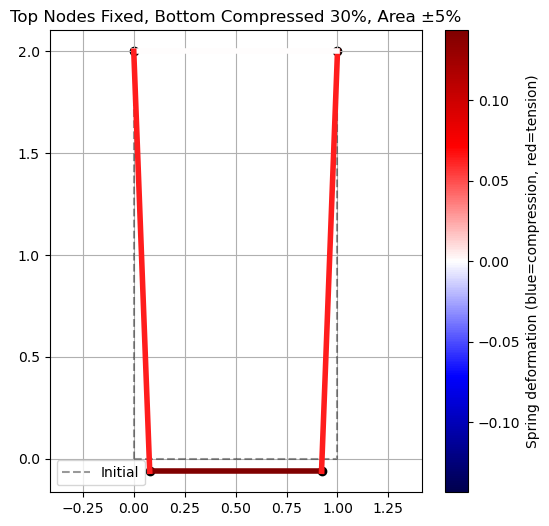

Spring Stiffness k: [1.0, 1.0, 1.0, 1.0]
Initial Spring Deformations (bottom,right,top,left): [0.3 0.  0.  0. ]
Final Spring Deformations (bottom,right,top,left): [0.143 0.063 0.    0.063]
Initial Area: 2.0
Final Area: 1.9
Initial Height: 2.0
Final Height: 2.0615


In [15]:
#top nodes fixed--not rigid bar, no lateral pre-tension, compression not strictly enforced, global shape optimization

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from scipy.optimize import minimize

# -------------------------------
# Parameters
# -------------------------------
width = 1.0
height = 2.0
bottom_compression = 0.7      # 30% compressed
area_relax = 0.05             # ±5% area allowed
tension_factor = 0.0          # 0% pre-tension in lateral springs

# -------------------------------
# Initial rectangle with lateral pre-tension
# -------------------------------
p0 = np.array([
    [0,0],
    [width,0],
    [width,height*(1+tension_factor)],
    [0,height*(1+tension_factor)]
])

edges = [(0,1),(1,2),(2,3),(3,0)]  # bottom, right, top, left
bottom_rest = width
rest_lengths = [bottom_rest, height, width, height]

# Spring stiffnesses (bottom, right, top, left)
k_values = [1.0, 1.0, 1.0, 1.0]

# Area limits
area0 = width * height
area_min = (1 - area_relax) * area0
area_max = (1 + area_relax) * area0

# Bottom target
bottom_target = bottom_rest * bottom_compression

# -------------------------------
# Helper functions
# -------------------------------
def area_quad(p):
    x, y = p[:,0], p[:,1]
    return 0.5 * abs(np.dot(x, np.roll(y,-1)) - np.dot(y, np.roll(x,-1)))

def spring_energy(p):
    f = 0.0
    for idx,(i,j) in enumerate(edges):
        L = np.linalg.norm(p[j] - p[i])
        if idx == 0:  # bottom spring uses compression target
            f += k_values[idx] * (L - bottom_target)**2
        else:
            f += k_values[idx] * (L - rest_lengths[idx])**2
    return f

# -------------------------------
# Fix top nodes (2 and 3)
# -------------------------------
fixed_nodes = [2, 3]
free_nodes = [0, 1]

Y0 = p0[free_nodes].flatten()

def reconstruct_full(Y_free):
    p = p0.copy()
    p[free_nodes] = Y_free.reshape((len(free_nodes), 2))
    return p

def energy_free(Y_free):
    p = reconstruct_full(Y_free)
    return spring_energy(p)

def area_constraint_free(Y_free):
    p = reconstruct_full(Y_free)
    A = area_quad(p)
    return [A - area_min, area_max - A]

constraints = [
    {'type': 'ineq', 'fun': lambda Y: area_constraint_free(Y)[0]},
    {'type': 'ineq', 'fun': lambda Y: area_constraint_free(Y)[1]}
]

# -------------------------------
# Optimization
# -------------------------------
res = minimize(
    energy_free,
    Y0,
    method='SLSQP',
    constraints=constraints,
    options={'ftol':1e-9, 'disp':True}
)

p_final = reconstruct_full(res.x)

# -------------------------------
# Compute spring forces (consistent with energy)
# -------------------------------
tensions = []
for idx,(i,j) in enumerate(edges):
    L = np.linalg.norm(p_final[j] - p_final[i])
    if idx == 0:
        tensions.append(L - bottom_target)
    else:
        tensions.append(L - rest_lengths[idx])

# -------------------------------
# Plotting
# -------------------------------
plt.figure(figsize=(6,6))

# Initial shape
pi = np.vstack([p0, p0[0]])
plt.plot(pi[:,0], pi[:,1], 'k--', alpha=0.4, label="Initial")

# Force coloring
max_mag = max(abs(t) for t in tensions) + 1e-6
norm = mcolors.TwoSlopeNorm(vmin=-max_mag, vcenter=0, vmax=max_mag)
cmap = plt.cm.seismic

for idx,(i,j) in enumerate(edges):
    x = [p_final[i,0], p_final[j,0]]
    y = [p_final[i,1], p_final[j,1]]
    plt.plot(x, y, color=cmap(norm(tensions[idx])), linewidth=4)

plt.scatter(p_final[:,0], p_final[:,1], color='black')

plt.axis('equal')
plt.grid(True)

sm = plt.cm.ScalarMappable(norm=norm, cmap=cmap)
sm.set_array([])
plt.colorbar(sm, ax=plt.gca(), label="Spring deformation (blue=compression, red=tension)")

plt.title("Top Nodes Fixed, Bottom Compressed 30%, Area ±5%")
plt.legend()
plt.show()

# -------------------------------
# Print results
# -------------------------------
print("Spring Stiffness k:", k_values)

initial_forces = []
for idx,(i,j) in enumerate(edges):
    L0 = np.linalg.norm(p0[j] - p0[i])
    if idx == 0:
        initial_forces.append(L0 - bottom_target)
    else:
        initial_forces.append(L0 - rest_lengths[idx])

print("Initial Spring Deformations (bottom,right,top,left):",
      np.round(initial_forces,3))

print("Final Spring Deformations (bottom,right,top,left):",
      np.round(tensions,3))

final_area = area_quad(p_final)
print("Initial Area:", area0)
print("Final Area:", np.round(final_area,4))

final_height = np.max(p_final[:,1]) - np.min(p_final[:,1])
print("Initial Height:", height)
print("Final Height:", np.round(final_height,4))

Optimization terminated successfully    (Exit mode 0)
            Current function value: 0.028475016867590387
            Iterations: 8
            Function evaluations: 74
            Gradient evaluations: 8


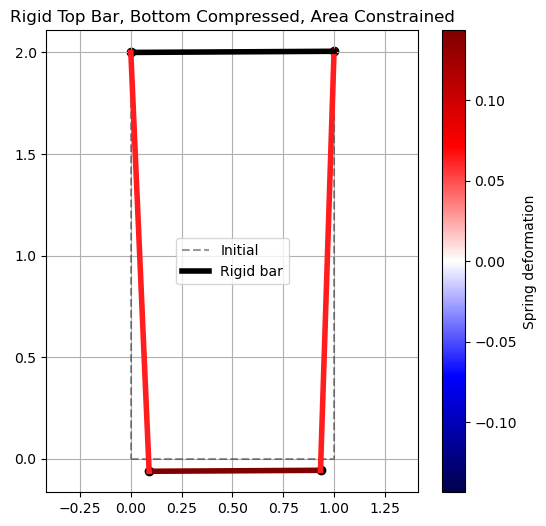

Final Node Positions:
 [[ 0.0901 -0.0611]
 [ 0.9334 -0.0563]
 [ 1.      2.0057]
 [ 0.      2.    ]]
Initial Height: 2.0
Final Height: 2.066755640792878
Final Area: 1.9000000000025825


In [20]:
#top is rigid bar, no lateral pre-tension, compression is not strictly enforced, global shape optimization

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from scipy.optimize import minimize

# -------------------------------
# Parameters
# -------------------------------
width = 1.0
height = 2.0
bottom_compression = 0.7
area_relax = 0.05
tension_factor = 0.0

# -------------------------------
# Initial rectangle
# -------------------------------
p0 = np.array([
    [0,0],
    [width,0],
    [width,height*(1+tension_factor)],
    [0,height*(1+tension_factor)]
])

edges = [(0,1),(1,2),(2,3),(3,0)]  # bottom, right, top, left
bottom_rest = width
rest_lengths = [bottom_rest, height, width, height]

# bottom, right, (top removed), left
k_values = [1.0, 1.0, 1.0, 1.0]

area0 = width * height
area_min = (1 - area_relax) * area0
area_max = (1 + area_relax) * area0

bottom_target = bottom_rest * bottom_compression

# -------------------------------
# Geometry helpers
# -------------------------------
def area_quad(p):
    x, y = p[:,0], p[:,1]
    return 0.5 * abs(np.dot(x, np.roll(y,-1)) - np.dot(y, np.roll(x,-1)))

# -------------------------------
# Energy (TOP SPRING REMOVED)
# -------------------------------
def spring_energy(p):
    f = 0.0
    for idx,(i,j) in enumerate(edges):
        if idx == 2:   # skip top spring (rigid bar now)
            continue
        L = np.linalg.norm(p[j] - p[i])
        if idx == 0:
            f += k_values[idx] * (L - bottom_target)**2
        else:
            f += k_values[idx] * (L - rest_lengths[idx])**2
    return f

# -------------------------------
# Constraints
# -------------------------------
def area_constraint(Y):
    p = Y.reshape((4,2))
    A = area_quad(p)
    return [A - area_min, area_max - A]

def top_bar_constraint(Y):
    p = Y.reshape((4,2))
    return np.linalg.norm(p[2] - p[3]) - rest_lengths[2]

# Pin node 3 to eliminate rigid-body motion
def pin_node3_x(Y):
    p = Y.reshape((4,2))
    return p[3,0] - p0[3,0]

def pin_node3_y(Y):
    p = Y.reshape((4,2))
    return p[3,1] - p0[3,1]

constraints = [
    {'type':'ineq', 'fun': lambda Y: area_constraint(Y)[0]},
    {'type':'ineq', 'fun': lambda Y: area_constraint(Y)[1]},
    {'type':'eq', 'fun': top_bar_constraint},
    {'type':'eq', 'fun': pin_node3_x},
    {'type':'eq', 'fun': pin_node3_y},
]

# -------------------------------
# Solve
# -------------------------------
Y0 = p0.flatten()

res = minimize(
    lambda Y: spring_energy(Y.reshape((4,2))),
    Y0,
    method='SLSQP',
    constraints=constraints,
    options={'ftol':1e-9, 'disp':True}
)

p_final = res.x.reshape((4,2))

# -------------------------------
# Compute deformations
# -------------------------------
tensions = []
for idx,(i,j) in enumerate(edges):
    if idx == 2:
        tensions.append(0.0)  # rigid bar carries constraint force
        continue
    L = np.linalg.norm(p_final[j] - p_final[i])
    if idx == 0:
        tensions.append(L - bottom_target)
    else:
        tensions.append(L - rest_lengths[idx])

# -------------------------------
# Plot
# -------------------------------
plt.figure(figsize=(6,6))

pi = np.vstack([p0,p0[0]])
plt.plot(pi[:,0],pi[:,1],'k--', alpha=0.4, label="Initial")

max_mag = max(abs(t) for t in tensions)+1e-6
norm = mcolors.TwoSlopeNorm(vmin=-max_mag,vcenter=0,vmax=max_mag)
cmap = plt.cm.seismic

for idx,(i,j) in enumerate(edges):
    x = [p_final[i,0], p_final[j,0]]
    y = [p_final[i,1], p_final[j,1]]
    if idx == 2:
        plt.plot(x,y,color='black',linewidth=4,label="Rigid bar")
    else:
        plt.plot(x,y,color=cmap(norm(tensions[idx])),linewidth=4)

plt.scatter(p_final[:,0],p_final[:,1],color='black')
plt.axis('equal')
plt.grid(True)

sm = plt.cm.ScalarMappable(norm=norm, cmap=cmap)
sm.set_array([])
plt.colorbar(sm, ax=plt.gca(), label="Spring deformation")

plt.title("Rigid Top Bar, Bottom Compressed, Area Constrained")
plt.legend()
plt.show()

# -------------------------------
# Print results
# -------------------------------
print("Final Node Positions:\n", np.round(p_final,4))

initial_height = np.max(p0[:,1]) - np.min(p0[:,1])
final_height = np.max(p_final[:,1]) - np.min(p_final[:,1])

print("Initial Height:", initial_height)
print("Final Height:", final_height)
print("Final Area:", area_quad(p_final))

Optimization terminated successfully    (Exit mode 0)
            Current function value: 0.11550871135319707
            Iterations: 7
            Function evaluations: 66
            Gradient evaluations: 7


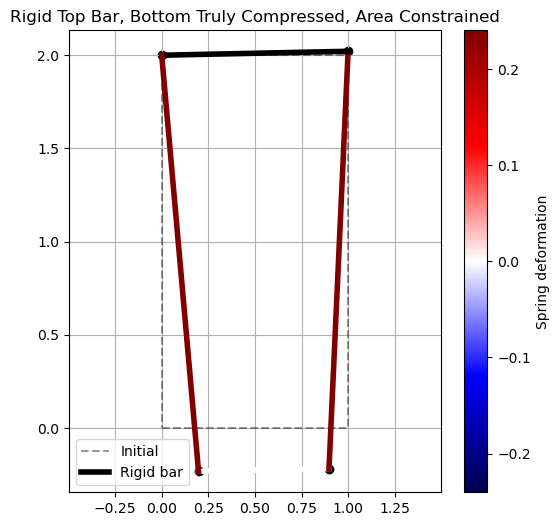

Final Node Positions:
 [[ 0.1974 -0.2316]
 [ 0.8973 -0.2167]
 [ 0.9998  2.0212]
 [ 0.      2.    ]]
Initial Height: 2.0
Final Height: 2.2528386723931217
Final Area: 1.8999999999999495
Bottom length (should equal compression): 0.7000000000005496


In [17]:
# top is rigid bar, no lateral pre-tension, true compression enforced

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from scipy.optimize import minimize

# -------------------------------
# Parameters
# -------------------------------
width = 1.0
height = 2.0
bottom_compression = 0.7       # true compressed length
area_relax = 0.05
tension_factor = 0.0

# -------------------------------
# Initial rectangle
# -------------------------------
p0 = np.array([
    [0,0],                          # bottom-left
    [width,0],                      # bottom-right
    [width,height*(1+tension_factor)],  # top-right
    [0,height*(1+tension_factor)]      # top-left
])

edges = [(0,1),(1,2),(2,3),(3,0)]  # bottom, right, top, left
bottom_rest = width
rest_lengths = [bottom_rest, height, width, height]

# bottom, right, (top removed), left
k_values = [1.0, 1.0, 5.0, 1.0]

area0 = width * height
area_min = (1 - area_relax) * area0
area_max = (1 + area_relax) * area0

# -------------------------------
# Geometry helpers
# -------------------------------
def area_quad(p):
    x, y = p[:,0], p[:,1]
    return 0.5 * abs(np.dot(x, np.roll(y,-1)) - np.dot(y, np.roll(x,-1)))

# -------------------------------
# Energy (TOP SPRING REMOVED)
# -------------------------------
def spring_energy(p):
    f = 0.0
    for idx,(i,j) in enumerate(edges):
        if idx == 2:   # skip top spring (rigid bar now)
            continue
        L = np.linalg.norm(p[j] - p[i])
        if idx == 0:
            continue  # bottom handled by constraint now
        else:
            f += k_values[idx] * (L - rest_lengths[idx])**2
    return f

# -------------------------------
# Constraints
# -------------------------------
def area_constraint(Y):
    p = Y.reshape((4,2))
    A = area_quad(p)
    return [A - area_min, area_max - A]

def top_bar_constraint(Y):
    p = Y.reshape((4,2))
    return np.linalg.norm(p[2] - p[3]) - rest_lengths[2]

def bottom_compression_constraint(Y):
    p = Y.reshape((4,2))
    return np.linalg.norm(p[1] - p[0]) - bottom_compression

# Pin node 3 to remove rigid-body motion
def pin_node3_x(Y):
    p = Y.reshape((4,2))
    return p[3,0] - p0[3,0]

def pin_node3_y(Y):
    p = Y.reshape((4,2))
    return p[3,1] - p0[3,1]

constraints = [
    {'type':'ineq', 'fun': lambda Y: area_constraint(Y)[0]},
    {'type':'ineq', 'fun': lambda Y: area_constraint(Y)[1]},
    {'type':'eq', 'fun': top_bar_constraint},
    {'type':'eq', 'fun': bottom_compression_constraint},  # NEW: true compression
    {'type':'eq', 'fun': pin_node3_x},
    {'type':'eq', 'fun': pin_node3_y},
]

# -------------------------------
# Solve
# -------------------------------
Y0 = p0.flatten()

res = minimize(
    lambda Y: spring_energy(Y.reshape((4,2))),
    Y0,
    method='SLSQP',
    constraints=constraints,
    options={'ftol':1e-9, 'disp':True}
)

p_final = res.x.reshape((4,2))

# -------------------------------
# Compute deformations
# -------------------------------
tensions = []
for idx,(i,j) in enumerate(edges):
    if idx == 2:   # top bar
        tensions.append(0.0)
        continue
    L = np.linalg.norm(p_final[j] - p_final[i])
    if idx == 0:
        tensions.append(L - bottom_compression)  # bottom is now a constraint
    else:
        tensions.append(L - rest_lengths[idx])

# -------------------------------
# Plot
# -------------------------------
plt.figure(figsize=(6,6))

pi = np.vstack([p0,p0[0]])
plt.plot(pi[:,0],pi[:,1],'k--', alpha=0.4, label="Initial")

max_mag = max(abs(t) for t in tensions)+1e-6
norm = mcolors.TwoSlopeNorm(vmin=-max_mag,vcenter=0,vmax=max_mag)
cmap = plt.cm.seismic

for idx,(i,j) in enumerate(edges):
    x = [p_final[i,0], p_final[j,0]]
    y = [p_final[i,1], p_final[j,1]]
    if idx == 2:
        plt.plot(x,y,color='black',linewidth=4,label="Rigid bar")
    else:
        plt.plot(x,y,color=cmap(norm(tensions[idx])),linewidth=4)

plt.scatter(p_final[:,0],p_final[:,1],color='black')
plt.axis('equal')
plt.grid(True)

sm = plt.cm.ScalarMappable(norm=norm, cmap=cmap)
sm.set_array([])
plt.colorbar(sm, ax=plt.gca(), label="Spring deformation")

plt.title("Rigid Top Bar, Bottom Truly Compressed, Area Constrained")
plt.legend()
plt.show()

# -------------------------------
# Print results
# -------------------------------
print("Final Node Positions:\n", np.round(p_final,4))

initial_height = np.max(p0[:,1]) - np.min(p0[:,1])
final_height = np.max(p_final[:,1]) - np.min(p_final[:,1])

print("Initial Height:", initial_height)
print("Final Height:", final_height)
print("Final Area:", area_quad(p_final))
print("Bottom length (should equal compression):", np.linalg.norm(p_final[1]-p_final[0]))

Optimization terminated successfully    (Exit mode 0)
            Current function value: 0.07244158573626494
            Iterations: 6
            Function evaluations: 55
            Gradient evaluations: 6


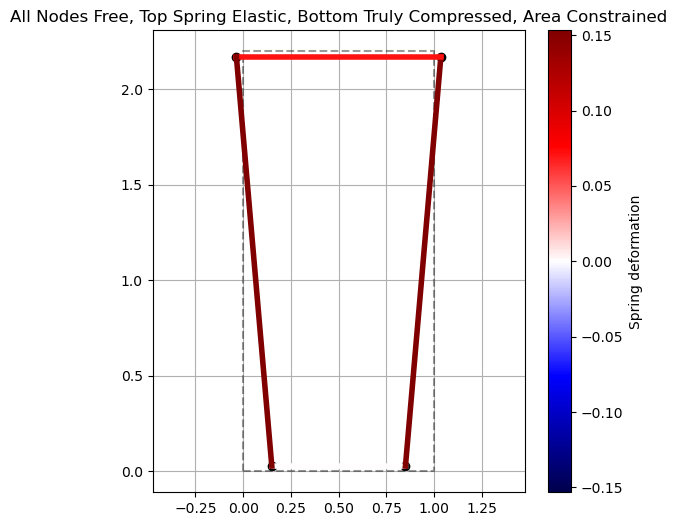

Final Node Positions:
 [[ 0.15    0.0274]
 [ 0.85    0.0274]
 [ 1.0357  2.1726]
 [-0.0357  2.1726]]
Initial Height: 2.2
Final Height: 2.145269902440498
Final Area: 1.8999999999367927
Bottom length (should equal compression): 0.7000000000005386
Spring deformations (bottom,right,top,left): [0.     0.1533 0.0713 0.1533]


In [13]:
#all nodes free, true compression enforced, 10% lateral pre-tension

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from scipy.optimize import minimize

# -------------------------------
# Parameters
# -------------------------------
width = 1.0
height = 2.0
bottom_compression = 0.7      # true compressed bottom
area_relax = 0.05             # area change of +/- 5% permitted
tension_factor = 0.1          # 10% lateral pre-tension

# -------------------------------
# Initial rectangle
# -------------------------------
p0 = np.array([
    [0,0],                          # bottom-left
    [width,0],                      # bottom-right
    [width,height*(1+tension_factor)],  # top-right
    [0,height*(1+tension_factor)]      # top-left
])

edges = [(0,1),(1,2),(2,3),(3,0)]  # bottom, right, top, left
bottom_rest = width
rest_lengths = [bottom_rest, height, width, height]

# Spring stiffnesses (bottom handled by constraint, top included)
k_values = [1.0, 1.0, 5.0, 1.0]  # bottom, right, top, left

area0 = width * height
area_min = (1 - area_relax) * area0
area_max = (1 + area_relax) * area0

# -------------------------------
# Geometry helpers
# -------------------------------
def area_quad(p):
    x, y = p[:,0], p[:,1]
    return 0.5 * abs(np.dot(x, np.roll(y,-1)) - np.dot(y, np.roll(x,-1)))

# -------------------------------
# Energy function (all springs except bottom)
# -------------------------------
def spring_energy(p):
    f = 0.0
    for idx,(i,j) in enumerate(edges):
        if idx == 0:
            continue  # bottom spring handled by constraint
        L = np.linalg.norm(p[j] - p[i])
        f += k_values[idx] * (L - rest_lengths[idx])**2
    return f

# -------------------------------
# Constraints
# -------------------------------
def area_constraint(Y):
    p = Y.reshape((4,2))
    A = area_quad(p)
    return [A - area_min, area_max - A]

def bottom_compression_constraint(Y):
    p = Y.reshape((4,2))
    return np.linalg.norm(p[1] - p[0]) - bottom_compression

constraints = [
    {'type':'ineq', 'fun': lambda Y: area_constraint(Y)[0]},
    {'type':'ineq', 'fun': lambda Y: area_constraint(Y)[1]},
    {'type':'eq', 'fun': bottom_compression_constraint},  # true bottom compression
]

# -------------------------------
# Solve
# -------------------------------
Y0 = p0.flatten()

res = minimize(
    lambda Y: spring_energy(Y.reshape((4,2))),
    Y0,
    method='SLSQP',
    constraints=constraints,
    options={'ftol':1e-9, 'disp': True}
)

p_final = res.x.reshape((4,2))

# -------------------------------
# Compute spring deformations
# -------------------------------
tensions = []
for idx,(i,j) in enumerate(edges):
    L = np.linalg.norm(p_final[j] - p_final[i])
    if idx == 0:
        tensions.append(L - bottom_compression)  # zero by constraint
    else:
        tensions.append(L - rest_lengths[idx])

# -------------------------------
# Plot
# -------------------------------
plt.figure(figsize=(6,6))

# Initial shape
pi = np.vstack([p0,p0[0]])
plt.plot(pi[:,0], pi[:,1], 'k--', alpha=0.4, label="Initial")

# Color coding
max_mag = max(abs(t) for t in tensions)+1e-6
norm = mcolors.TwoSlopeNorm(vmin=-max_mag,vcenter=0,vmax=max_mag)
cmap = plt.cm.seismic

for idx,(i,j) in enumerate(edges):
    x = [p_final[i,0], p_final[j,0]]
    y = [p_final[i,1], p_final[j,1]]
    plt.plot(x, y, color=cmap(norm(tensions[idx])), linewidth=4)

plt.scatter(p_final[:,0], p_final[:,1], color='black')
plt.axis('equal')
plt.grid(True)

sm = plt.cm.ScalarMappable(norm=norm, cmap=cmap)
sm.set_array([])
plt.colorbar(sm, ax=plt.gca(), label="Spring deformation")

plt.title("All Nodes Free, Top Spring Elastic, Bottom Truly Compressed, Area Constrained")
plt.show()

# -------------------------------
# Print results
# -------------------------------
print("Final Node Positions:\n", np.round(p_final,4))

initial_height = np.max(p0[:,1]) - np.min(p0[:,1])
final_height = np.max(p_final[:,1]) - np.min(p_final[:,1])

print("Initial Height:", initial_height)
print("Final Height:", final_height)
print("Final Area:", area_quad(p_final))
print("Bottom length (should equal compression):", np.linalg.norm(p_final[1]-p_final[0]))
print("Spring deformations (bottom,right,top,left):", np.round(tensions,4))